# Task 4.2 실제 하드웨어에서 회로 실행하기

**개요:** 이 노트북에서는 실제 양자 하드웨어에서 회로를 실행하는 방법을 다룹니다.

*   실제 하드웨어에서의 **실행 절차**
*   **프리미티브(Primitives):** Sampler, Estimator, 각 구현체와 입력/출력 구조
*   **브로드캐스팅 규칙:** 파라미터 집합과 observable을 이용해 기대값을 효율적으로 계산하는 방법
*   **세션 실행(Session execution):** 세션을 열고, 닫고, 세부 정보를 확인하는 방법


In [1]:
# 필요한 라이브러리 가져오기
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeTorino
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import Parameter
import numpy as np

np.set_printoptions(precision=3, suppress=True)

print("라이브러리를 성공적으로 불러왔습니다.")


라이브러리를 성공적으로 불러왔습니다.


## 목표 1 : 타깃 하드웨어에서 실행하기

실제 하드웨어에서 양자 회로를 실행하려면 보통 다음 단계를 거칩니다.

1. **인증(Authentication)**: IBM Quantum Runtime 서비스에 연결
2. **백엔드 선택(Backend Selection)**: 사용 가능한 양자 프로세서 선택
3. **회로 준비(Circuit Preparation)**: 하드웨어 제약에 맞게 회로 transpile
4. **작업 제출(Job Submission)**: 회로 실행 요청 전송
5. **결과 조회(Result Retrieval)**: 측정 결과를 가져와 분석


<span style="color:red"> **아래 셀을 실행하면 IBM 계정 크레딧이 약 10~15초 정도 사용됩니다.**
</span>

In [2]:
# 예시: 실제 하드웨어에서 양자 회로 실행하기

# --- 1단계: 인증 ---
# 계정 정보가 이미 저장되어 있다면 이를 자동으로 불러옵니다.
# service = QiskitRuntimeService()
# <instance_name>을 자신의 인스턴스 이름으로 바꾸세요.
# <token>을 자신의 IBM Quantum API 토큰으로 바꾸세요.
# 인스턴스와 토큰을 직접 지정해야 한다면 아래 줄의 주석을 해제하여 사용하세요.
# service = QiskitRuntimeService(channel="ibm_cloud", instance="<instance_name>", token="<token>")

# --- 2단계: 백엔드 선택 ---
# 실제 하드웨어만 대상으로, 큐 대기 시간을 줄이기 위해 가장 한가한 백엔드를 선택합니다.
backend = AerSimulator().from_backend(FakeTorino())
# backend = service.least_busy(operational=True, simulator=False)
print(f"사용 중인 백엔드: {backend.name}")
print(f"백엔드 정보: {backend.num_qubits} 큐비트")

# --- 3단계: 회로 준비 ---
# 간단한 Bell 상태 회로 생성
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

# 회로 시각화
qc.draw('mpl')

# 특정 하드웨어 백엔드에 맞게 회로를 transpile
# 백엔드의 네이티브 게이트 집합, 큐비트 연결성, 최적화 레벨(0~3, 3이 가장 강한 최적화)을 반영합니다.
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
transpiled_circuit = pm.run(qc)

# 측정할 observable 정의 (예: ZZ 상관관계)
ZZ = SparsePauliOp.from_list([("ZZ", 1)])

# --- 4단계: 작업 제출 ---
# Estimator 인스턴스를 만들고 작업을 실행합니다.
estimator = Estimator(mode=backend)

# observable을 transpiled 회로의 레이아웃에 맞게 매핑
observables = [ZZ.apply_layout(transpiled_circuit.layout)]

# 작업 제출
job = estimator.run([(transpiled_circuit, observables)])
print(f"\n작업 ID: {job.job_id()}")
print("작업이 성공적으로 제출되었습니다. 상태는 IBM Quantum 대시보드에서 확인하세요.")


사용 중인 백엔드: aer_simulator_from(fake_torino)
백엔드 정보: 133 큐비트

작업 ID: 3d409604-ee84-4b0d-83f5-7cd1181da188
작업이 성공적으로 제출되었습니다. 상태는 IBM Quantum 대시보드에서 확인하세요.


In [3]:
# --- 5단계: 결과 조회 ---
result = job.result()
print(f"기대값: {result[0].data.evs}")


기대값: [0.962]


## 목표 2: 프리미티브 이해하기

프리미티브는 하드웨어별 세부 사항을 추상화하는 기본 양자 연산입니다. 공통적인 양자 작업에 대해 표준화된 인터페이스를 제공합니다.

### 프리미티브:

**1. Sampler**:
- **용도**: 양자 회로의 측정 결과를 샘플링
- **출력**: counts 또는 확률 분포

**2. Estimator**:
- **용도**: observable의 기대값 계산
- **출력**: 기대값 ± 표본 오차, 하드웨어 오류

### 프리미티브 구현체:

**기반 클래스(Base Classes)**:
- `BaseSamplerV2`: sampler의 기반 클래스이며, 모든 sampler 구현체는 이 클래스를 상속합니다.
- `BaseEstimatorV2`: estimator의 기반 클래스이며, 모든 estimator 구현체는 이 클래스를 상속합니다.

**V2 프리미티브**:
- `SamplerV2`: 향상된 기능을 제공하는 최신 sampler
- `EstimatorV2`: 향상된 기능을 제공하는 최신 estimator


<span style="color:red"> **아래 셀을 실행하면 IBM 계정 크레딧이 약 5~10초 정도 사용됩니다.** </span>

In [4]:
# 예시: Sampler 프리미티브 사용하기
# Sampler 프리미티브는 양자 회로를 실행하고 측정 통계를 반환합니다.

# 현재 백엔드에 연결된 Sampler 인스턴스 생성
sampler = Sampler(mode=backend)

# 'shots' 파라미터는 회로를 몇 번 실행할지를 결정합니다.
shots = 1024

# transpile된 Bell 상태 회로를 샘플링 작업으로 제출
job = sampler.run([transpiled_circuit], shots=shots)

print(f"Sampler 작업 ID: {job.job_id()}")
print(f"요청한 shots 수: {shots}")


Sampler 작업 ID: a420eb57-0e62-43c4-ada2-224f3e35a4e0
요청한 shots 수: 1024


In [5]:
# 결과 가져오기
result = job.result()
counts = result[0].data.c.get_counts()
print(f"\n측정 카운트: {counts}")



측정 카운트: {'11': 518, '00': 488, '10': 10, '01': 8}


## 목표 3: 프리미티브의 입력과 출력

### 입력

#### Sampler 입력 구조

각 Sampler **Pub**(Primitive Unified Bloc)은 다음을 받습니다.
1. **양자 회로(Quantum Circuit)**: 실행할 회로  
   (샘플링할 큐비트에 대한 측정이 포함되어 있어야 함)
2. **파라미터(Parameters)**: 파라미터화된 회로의 파라미터 값  
   (회로가 파라미터화되어 있을 때만 필요)
3. **Shots**: 회로 실행 횟수 (선택 사항)

#### Estimator 입력 구조

각 Estimator **Pub**은 다음을 받습니다.
1. **양자 회로(Quantum Circuit)**: 실행할 회로  
   (타깃 백엔드에 맞게 transpile되어 있어야 함)
2. **Observable**: 측정할 하나 이상의 observable  
   (`Pauli`, `SparsePauliOp`, `PauliList`, `str` 객체 가능)
3. **파라미터(Parameters)**: 파라미터화된 회로의 파라미터 값 (선택 사항)
4. **정밀도(Precision)**: 오류 완화를 위한 목표 정밀도 (선택 사항)


<span style="color:red"> **아래 셀을 실행하면 IBM 계정 크레딧이 약 5분 정도 사용됩니다.**
</span>

In [6]:
# 예시 1: 여러 파라미터와 observable에 대해 Estimator 프리미티브 사용하기
# --- 파라미터화된 회로 생성 ---
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.ry(Parameter("a"), 0)    # 파라미터화된 Y 회전
circuit.rz(Parameter("b"), 0)    # 파라미터화된 Z 회전
circuit.cx(0, 1)
circuit.h(0)

# 파라미터화된 회로 표시
print("파라미터화된 회로:")
circuit.draw('mpl')

# --- 하드웨어에 맞게 transpile ---
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
transpiled_circuit = pm.run(circuit)
layout = transpiled_circuit.layout

# --- 파라미터 스윕 정의 ---
# 서로 다른 100개의 파라미터 조합 생성
# Shape: (100, 2) 여기서 100은 파라미터 집합의 수, 2는 각 집합의 파라미터 개수
params = np.vstack([
    np.linspace(-np.pi, np.pi, 100),         # 파라미터 'a' 값
    np.linspace(-4 * np.pi, 4 * np.pi, 100)  # 파라미터 'b' 값
]).T

print(f"\n파라미터 배열 shape: {params.shape}")
print(f"처음 5개 파라미터 집합:\n{params[:5]}")

# --- 여러 observable 정의 ---
# 각 파라미터 집합에 대해 세 가지 서로 다른 observable을 측정
# Shape: (3, 1) 여기서 3은 observable 집합의 수, 1은 각 집합의 observable 개수
observables = [
    [SparsePauliOp(["XX", "IY"], [0.5, 0.5])],   # XX와 IY의 선형 결합
    [SparsePauliOp("XX")],                       # XX
    [SparsePauliOp("IY")],                       # IY
]

# transpile된 회로와 동일한 레이아웃 적용
observables = [
    [observable.apply_layout(layout) for observable in observable_set]
    for observable_set in observables
]

print(f"\nObservable 집합 수: {len(observables)}")
print(f"집합당 observable 개수: {len(observables[0])}")

# --- Estimator Pub 생성 ---
# 총 계산 수: 회로 1개 × observable 3개 × 파라미터 집합 100개 = 기대값 300개
estimator_pub = (transpiled_circuit, observables, params)

# --- Estimator로 실행 ---
estimator = Estimator(mode=backend)
job = estimator.run([estimator_pub])

print(f"\n작업이 제출되었습니다! 작업 ID: {job.job_id()}")


파라미터화된 회로:

파라미터 배열 shape: (100, 2)
처음 5개 파라미터 집합:
[[ -3.142 -12.566]
 [ -3.078 -12.313]
 [ -3.015 -12.059]
 [ -2.951 -11.805]
 [ -2.888 -11.551]]

Observable 집합 수: 3
집합당 observable 개수: 1

작업이 제출되었습니다! 작업 ID: 386f6cf9-6b47-4fef-898e-083f2464e9f0


In [7]:
# --- 결과 처리 ---
result = job.result()
print(f"\n결과 shape: {result[0].data.evs.shape}")  # 예상 shape: (3, 100)
print(f"처음 몇 개의 기대값: {result[0].data.evs[:, :5]}")



결과 shape: (3, 100)
처음 몇 개의 기대값: [[-0.009  0.094  0.182  0.276  0.342]
 [-0.004  0.036  0.055  0.123  0.162]
 [-0.013  0.151  0.309  0.429  0.521]]


#### 브로드캐스팅 규칙

브로드캐스팅을 사용하면 하나의 primitive 호출로 여러 파라미터 집합과 여러 observable에 대한 기대값을 효율적으로 계산할 수 있습니다. 규칙은 NumPy의 [broadcasting 규칙](https://quantum.cloud.ibm.com/docs/en/guides/primitive-input-output#broadcasting-rules)을 따릅니다.

![broadcasting.png](./images/broadcasting.png)

- 입력 배열은 차원 수(`a.ndim` or `len(a.shape)`)가 서로 같을 필요가 없습니다.
   - 결과 배열의 차원 수는 입력들 중 차원이 가장 큰 배열과 같습니다.
   - 각 차원의 크기는 대응되는 차원들 중 가장 큰 크기를 따릅니다.
   - 없는 차원은 크기가 1인 것으로 간주합니다.
- shape 비교는 가장 오른쪽 차원부터 시작해서 왼쪽으로 진행합니다.
- 두 차원은 크기가 같거나, 둘 중 하나가 1이면 호환됩니다.

##### 예시

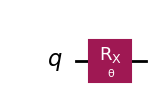

In [8]:
simulator = AerSimulator()

# 파라미터화된 1큐비트 회로
theta = Parameter("θ")
qc = QuantumCircuit(1)
qc.rx(theta, 0)

# Estimator 프리미티브
estimator = Estimator(mode=simulator)

pm = generate_preset_pass_manager(optimization_level=1, backend=simulator)
transpiled_circuit = pm.run(qc)
transpiled_circuit.draw('mpl')


In [9]:
# 브로드캐스팅 예시 1: 단일 observable과 파라미터 집합
# 파라미터 값:    (5 × 1)
# Observable:     (1 × 1)
#--------------------------------
# 출력:           (5 × 1)

parameter_values = [[v] for v in np.linspace(0, np.pi, 5)]
observable = SparsePauliOp("Z")
estimator_pub = (transpiled_circuit, observable, parameter_values)
job = estimator.run([estimator_pub])
result = job.result()
print(result[0].data.evs)
print(f"입력 shape: {np.array(parameter_values).shape} , {np.array(observable).shape[:-2]}")
print(f"출력 shape: {result[0].data.evs.shape}")


[ 1.     0.72  -0.002 -0.706 -1.   ]
입력 shape: (5, 1) , ()
출력 shape: (5,)


In [10]:
np.array(observable)

array([[ 1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]])

In [11]:
# 브로드캐스팅 예시 2: 파라미터와 observable의 Zip 결합
# 파라미터 값:    (5 × 1)
# Observable:     (5 × 1)
#--------------------------------
# 출력:           (5 × 1)

parameter_values = [[v] for v in np.linspace(0, np.pi, 5)]

observables = [
    SparsePauliOp("Z"),
    SparsePauliOp("X"),
    SparsePauliOp("Y"),
    SparsePauliOp("Z"),
    SparsePauliOp("X"),
]

estimator_pub = (transpiled_circuit, observables, parameter_values)
job = estimator.run([estimator_pub])
result = job.result()
print(result[0].data.evs)
print(f"입력 shape: {np.array(parameter_values).shape} , {np.array(observables).shape[:-2]}")
print(f"출력 shape: {result[0].data.evs.shape}")


[ 1.     0.011 -1.    -0.715  0.031]
입력 shape: (5, 1) , (5,)
출력 shape: (5,)


In [12]:
# 브로드캐스팅 예시 3: Outer Product (전체 브로드캐스트)
# 파라미터 값:    (1 × 6)
# Observable:     (4 × 1)
#--------------------------------
# 출력:           (4 × 6)

parameter_values = [np.linspace(0, np.pi, 6).tolist()]

observables = [
    [SparsePauliOp("Z")],
    [SparsePauliOp("X")],
    [SparsePauliOp("Y")],
    [SparsePauliOp("I")],
]

estimator_pub = (transpiled_circuit, observables, parameter_values)
job = estimator.run([estimator_pub])
result = job.result()
print(result[0].data.evs)
print(f"입력 shape: {np.array(parameter_values).shape} , {np.array(observables).shape[:-2]}")
print(f"출력 shape: {result[0].data.evs.shape}")


[[ 1.     0.784  0.321 -0.26  -0.811 -1.   ]
 [ 0.01   0.01  -0.007  0.005 -0.019  0.036]
 [ 0.003 -0.626 -0.95  -0.952 -0.583 -0.055]
 [ 1.     1.     1.     1.     1.     1.   ]]
입력 shape: (1, 6) , (4, 1)
출력 shape: (4, 6)


In [13]:
# 브로드캐스팅 예시 4: N차원 일반화 (여러 observable 배열)
# 파라미터 값:    (3 × 6)
# 2개 observable 배열: (3 × 1)
#--------------------------------
# 출력:           2 * (3 × 6)
parameter_values = [
    np.linspace(0, np.pi, 6).tolist(),
    np.linspace(np.pi, 2*np.pi, 6).tolist(),
    np.linspace(2*np.pi, 3*np.pi, 6).tolist(),
]

observables_a = [
    [SparsePauliOp("Z")],
    [SparsePauliOp("X")],
    [SparsePauliOp("Y")],
]

observables_b = [
    [SparsePauliOp("X")],
    [SparsePauliOp("Y")],
    [SparsePauliOp("Z")],
]

estimator_pub = (transpiled_circuit, [observables_a, observables_b], parameter_values)

job = estimator.run([estimator_pub])
result = job.result()
print(result[0].data.evs)
print(f"입력 shape: {np.array(parameter_values).shape} , {np.array([observables_a, observables_b]).shape[:-2]}")
print(f"출력 shape: {result[0].data.evs.shape}")


[[[ 1.     0.816  0.308 -0.319 -0.822 -1.   ]
  [ 0.021 -0.008 -0.028  0.004  0.013 -0.   ]
  [ 0.005 -0.559 -0.947 -0.956 -0.583 -0.016]]

 [[-0.018 -0.003  0.026 -0.002 -0.    -0.008]
  [-0.003  0.578  0.951  0.948  0.563 -0.005]
  [ 1.     0.811  0.304 -0.331 -0.807 -1.   ]]]
입력 shape: (3, 6) , (2, 3, 1)
출력 shape: (2, 3, 6)


### 출력

`result` 객체가 반환하는 데이터는 `PubResult`의 리스트입니다. 이 리스트의 각 원소는 primitive의 `run` 메서드에 입력으로 전달한 각 PUB에 대응합니다.

#### Sampler 출력 구조:

```
└── PrimitiveResult
    ├── PubResult[0]
    │   ├── metadata
    │   └── data  ## DataBin 객체 형태
    │       ├── NAME_OF_CLASSICAL_REGISTER
    │       │   └── 카운트 데이터가 들어 있는 BitArray (기본값은 'meas')
    |       |
    │       └── NAME_OF_ANOTHER_CLASSICAL_REGISTER
    │           └── BitArray 형태의 카운트 데이터
    |                 (회로에 ClassicalRegister가 둘 이상 지정된 경우에만 존재)
    ├── PubResult[1]
    |   ├── metadata
    |   └── data  ## DataBin 객체 형태
    |       └── NAME_OF_CLASSICAL_REGISTER
    |           └── 두 번째 pub에 대한 카운트 데이터가 들어 있는 BitArray
    ├── ...
    ├── ...
    └── ...
```

##### Estimator 출력 구조:

```
└── PrimitiveResult
    ├── PubResult[0]
    │   ├── metadata
    │   └── data  ## DataBin 객체 형태
    │       ├── evs
    │       │   └── 첫 번째 pub에서 지정한 shape에 맞는
    |       |         추정 기대값 리스트
    │       └── stds
    │           └── evs와 같은 shape을 갖는 표준 편차 리스트
    ├── PubResult[1]
    |   ├── metadata
    |   └── data
    │       ├── evs
    │       │   └── 두 번째 pub에 대한 추정 기대값 리스트
    │       └── stds
    │           └── 두 번째 pub에 대한 표준 편차 리스트
    ├── ...
    ├── ...
    └── ...
```


<span style="color:red"> **아래 셀을 실행하면 IBM 계정 크레딧이 약 5초 정도 사용됩니다.**
</span>

GHZ 상태 회로 (10큐비트):


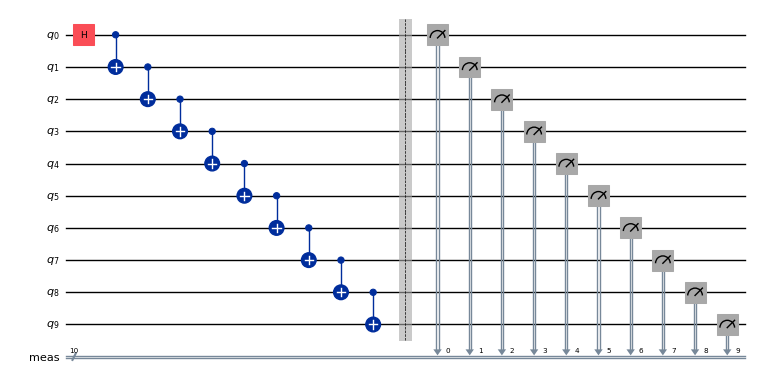

In [14]:
# 예시 2: 결과 처리
# --- 10큐비트 GHZ 회로 생성 ---
# GHZ 상태는 최대 얽힘 상태입니다: (|0...0⟩ + |1...1⟩)/√2
circuit = QuantumCircuit(10)
circuit.h(0)
circuit.cx(range(0, 9), range(1, 10))
circuit.measure_all()

print("GHZ 상태 회로 (10큐비트):")
circuit.draw('mpl', fold=-1, scale=0.5)  # 회로 그림을 접지 않고 표시

In [15]:
# --- 하드웨어에 맞게 transpile ---
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
transpiled_circuit = pm.run(circuit)
sampler_pub = [transpiled_circuit]

# --- Sampler로 실행 ---
sampler = Sampler(mode=backend)
job = sampler.run(sampler_pub, shots=1000)
print(f"Sampler 작업 ID: {job.job_id()}")

Sampler 작업 ID: 93919c71-2f0e-4b8d-b6c4-a1fa7e68192f


In [16]:
result = job.result()

print("\n=== SAMPLER 결과 분석 ===\n")

# 1. data bin 접근
data = result[0].data
print(f"DataBin 내용: {data}")
print(f"사용 가능한 레지스터: {list(data.keys())}\n")

# 2. BitArray 접근
# 'meas'는 measure_all()이 생성하는 기본 classical register 이름입니다.
bit_array = data.meas
print(f"BitArray 타입: {type(bit_array)}")
print(f"BitArray shape: {bit_array.array.shape}") # 1000 shots × 10 bits => 1000 shots × 2 bytes

# 3. 원시 측정 데이터 확인
for i in range(min(10, bit_array.array.shape[0])):
    print(f"   Shot {i}: {bit_array.array[i]}")

# 4. counts 딕셔너리로 변환
counts = bit_array.get_counts()
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
print(f"\n측정 카운트(모든 결과):")
for outcome, count in sorted_counts:
    print(f"   {outcome}: {count} shots ({count/1000*100:.1f}%)")



=== SAMPLER 결과 분석 ===

DataBin 내용: DataBin(meas=BitArray(<shape=(), num_shots=1000, num_bits=10>))
사용 가능한 레지스터: ['meas']

BitArray 타입: <class 'qiskit.primitives.containers.bit_array.BitArray'>
BitArray shape: (1000, 2)
   Shot 0: [0 0]
   Shot 1: [0 0]
   Shot 2: [0 0]
   Shot 3: [ 0 16]
   Shot 4: [0 0]
   Shot 5: [0 0]
   Shot 6: [  3 251]
   Shot 7: [ 0 65]
   Shot 8: [0 0]
   Shot 9: [0 0]

측정 카운트(모든 결과):
   0000000000: 422 shots (42.2%)
   1111111111: 374 shots (37.4%)
   1111111110: 28 shots (2.8%)
   1111101111: 18 shots (1.8%)
   0000010000: 16 shots (1.6%)
   0000000001: 16 shots (1.6%)
   1111111101: 10 shots (1.0%)
   0000100000: 9 shots (0.9%)
   1110111111: 8 shots (0.8%)
   0010000000: 8 shots (0.8%)
   1011111111: 8 shots (0.8%)
   0001000000: 7 shots (0.7%)
   1111011111: 6 shots (0.6%)
   0111111111: 6 shots (0.6%)
   0100000000: 6 shots (0.6%)
   1111111011: 5 shots (0.5%)
   0000111111: 5 shots (0.5%)
   0000000100: 4 shots (0.4%)
   0000001000: 4 shots (0.4%)
   11

In [17]:
# 필요하다면 기본 BitArray 형식 대신 딕셔너리 형식으로 변환할 수 있습니다.
counts = data.meas.get_counts()
print(f"Counts: {counts}")


Counts: {'0000000000': 422, '0000010000': 16, '1111111011': 5, '0001000001': 1, '1111111111': 374, '0001000000': 7, '0000000100': 4, '1111111110': 28, '1111101111': 18, '0000000001': 16, '1110111111': 8, '0010000000': 8, '1111111100': 1, '1111011110': 1, '1110000000': 3, '0011001111': 1, '0000001000': 4, '0000100000': 9, '1111011111': 6, '1111000000': 2, '0111111111': 6, '0100000000': 6, '1111111101': 10, '1111100000': 1, '0000011111': 1, '0011111111': 3, '1101111111': 4, '0100000001': 1, '1011111111': 8, '0000000010': 3, '0000010001': 1, '0000111111': 5, '0100010000': 1, '0000000101': 1, '0000000111': 1, '1111110111': 3, '0000000011': 1, '0000101000': 1, '0010000100': 1, '1111110110': 1, '0001111111': 1, '1000000000': 1, '1100111111': 1, '0110000000': 1, '0000001111': 2, '1101101111': 1}


## 목표 4 : 작업 세션(Session) 실행하기

세션은 같은 양자 하드웨어에서 여러 관련 작업을 효율적으로 실행하는 방법을 제공합니다. 작업들 사이의 문맥을 유지하므로 오버헤드를 줄이고, 반복형 알고리즘의 성능을 개선할 수 있습니다.

**Session**은 다음을 제공하는 실행 Context입니다.
1. 여러 작업을 위해 **하드웨어 시간을 확보**
2. 작업들 사이에서 **회로 Context 유지**
3. 반복형 알고리즘에서 **오버헤드 감소**
4. 관련된 작업들에 대해 **일관된 하드웨어 조건 보장**

**세션 수명 주기(Session Lifecycle):**
1. **열기(Open)**: 특정 백엔드로 세션 생성
2. **사용(Use)**: 세션 안에서 여러 작업 실행
3. **닫기(Close)**: 명시적으로 닫거나 timeout으로 종료

**주요 파라미터:**
- **TTL (Time To Live)**: 세션의 최대 지속 시간 (기본값: 8시간)
- **Max Time**: 세션 내에서 허용되는 최대 작업 실행 시간

![batch_session](./images/batch_session.png)

<span style="color:red"> **참고: Open plan 사용자는 session execution 모드로 작업을 실행할 수 없습니다. 따라서 이 이후의 코드 블록들은 Open plan에서는 실패합니다.** </span>

### 세션 열기

이는 `Session` 클래스를 직접 초기화하거나, `with Session()` 형태의 컨텍스트 매니저를 사용하여 수행할 수 있습니다.

In [18]:
from qiskit_ibm_runtime import (
    Session,
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator,
)

session = Session(backend=backend)
estimator = Estimator(mode=session)
sampler = Sampler(mode=session)
# 컨텍스트 매니저를 사용하지 않았으므로 세션을 직접 닫습니다.
session.close()


In [19]:
from qiskit_ibm_runtime import (
    Session,
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator,
)
 
# backend = service.least_busy(operational=True, simulator=False)
# with Session(backend=backend):
#     estimator = Estimator()
#     sampler = Sampler()

### 세션 길이

`Batch`와 유사하게, 세션의 최대 TTL은 `max_time`으로 지정할 수 있습니다. 세션이 시작되면 시간이 흐르기 시작하며, 최대 시간이 되면 세션은 닫힙니다. 이때 이미 실행 중인 작업은 끝까지 수행되지만, 대기 중인 작업은 실패합니다.

| 플랜 종류 | 최대 작업 지속 시간 |
|-----------|-----------------------|
| Premium Plans | 8시간 |

추가로, 설정할 수 없는 interactive TTL(1분)도 존재합니다. 이 시간 창 안에 세션 작업이 큐에 들어오지 않으면 세션은 일시적으로 비활성화됩니다.


### 세션 종료

다음 중 하나가 발생하면 세션은 닫힙니다.

* TTL에 도달한 경우
* `session.close()`를 사용해 수동으로 취소하거나 종료한 경우
* 컨텍스트 매니저 안에서 사용되어 블록이 끝나며 자동으로 닫힌 경우

세션이 닫히면 더 이상 새 작업을 받을 수 없습니다. 다만 이미 제출된 작업은 계속 실행됩니다.


In [20]:
'''
session = Session(backend=backend)

estimator = Estimator(mode=session)
sampler = Sampler(mode=session)
job1 = estimator.run([estimator_pub])
job2 = sampler.run([sampler_pub])
print(f"결과 1: {job1.result()}")
print(f"결과 2: {job2.result()}")

# 세션을 수동으로 종료합니다. 실행 중이거나 큐에 있는 작업은 끝까지 수행됩니다.
session.close()
'''

None

### 세션 상태 확인

세션 상태는 <code>session.status()</code>로 확인할 수 있으며, 다음 중 하나입니다.

* Pending
* In Progress, accepting new jobs
* In Progress, not accepting new jobs : 이미 제출된 작업은 완료되며, 이후 세션이 닫힘
* Closed


### 세션 세부 정보 확인

In [21]:
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    EstimatorV2 as Estimator,
)
'''  
with Session(backend=backend) as session:
    print(session.details())
'''
None

### 사용 패턴

세션은 고전 자원과 양자 자원 사이에 상호작용이 필요한 알고리즘에서 특히 유용합니다.
예를 들어,

* SCiPy를 사용해 비용 함수를 최소화하는 반복형 워크로드 실행
* 세션 안에서 VQE 알고리즘 실행


---
## 요약
---

이 노트북에서는 다음을 다루었습니다.

## 실제 하드웨어에서 회로 실행하기:

1. **실제 하드웨어 실행**은 인증, 백엔드 선택, 회로 준비, 작업 제출, 결과 조회의 단계로 이루어집니다.
2. **Qiskit runtime primitive**는 하드웨어별 세부 사항을 추상화하는 표준 인터페이스입니다.
3. **Sampler**는 회로의 측정값 또는 counts를 반환하고, **Estimator**는 observable의 기대값을 반환합니다.
4. **브로드캐스팅 규칙**은 여러 observable 집합과 파라미터 값에 대해 기대값을 계산할 때 사용됩니다.
5. **세션 모드**는 QPU를 독점적으로 활용하는 실행 방식이며, 고전 정보와 양자 정보가 반복적으로 오가는 워크플로우에 특히 적합합니다.


---

## 연습 문제

---

**1) 다음은 특정 시간 제한을 두고 batch를 생성하는 코드입니다.**

```
from qiskit_ibm_runtime import Batch, SamplerV2 as Sampler

# 30분 max_time을 갖는 batch 생성
with Batch(backend=backend, max_time="30m") as batch:
    sampler = Sampler()

    # 첫 번째 작업을 즉시 제출
    job1 = sampler.run([circuit1], shots=1000)
    print(f"Job1 submitted at: {datetime.now()}")

    # 두 번째 작업 제출 전 2분 대기
    time.sleep(120)
    job2 = sampler.run([circuit2], shots=1000)
    print(f"Job2 submitted at: {datetime.now()}")

    # 결과 가져오기
    result1 = job1.result()
    result2 = job2.result()
```

어느 설명이 올바른가요?

A) `max_time="30m"`은 batch가 생성 시점부터 작업 활동과 무관하게 정확히 30분 동안 열린다는 뜻이다.

B) `job2`가 끝난 뒤 1분 동안 새 작업이 제출되지 않으면, interactive TTL 때문에 batch는 "일시적으로 비활성화된" 상태가 된다.

C) interactive TTL(1분)은 설정 가능하며, `interactive_ttl="5m"` 같은 추가 파라미터로 늘릴 수 있다.

D) `job2`가 완료되는 데 29분이 걸리면, 30분 중 1분이 남아 있더라도 batch는 즉시 닫힌다.


**정답:**
<details> <br/>

B) `job2`가 끝난 뒤 1분 동안 새 작업이 제출되지 않으면, interactive TTL 때문에 batch는 "일시적으로 비활성화된" 상태가 된다.

</details>

---

**2) 어떤 상황에서 session 모드가 가장 적절한가요?**

A) 한 작업의 결과가 다음 작업에 영향을 주는 반복형 워크로드

B) 서로 문맥을 공유하지 않는 많은 독립 작업 제출

C) 하나의 회로를 한 번만 실행

D) 비용 최소화가 최우선일 때


**정답:**
<details> <br/>
A) 한 작업의 결과가 다음 작업에 영향을 주는 반복형 워크로드

Session 모드는 반복형 또는 상호작용형 워크로드를 위해 설계되었습니다.
</details>

---

**3) 다음 예시에 적용된 broadcasting 규칙은 무엇인가요?**

```
params = [[0.1], [0.2], [0.3]]

observables = [
    SparsePauliOp("Z"),
    SparsePauliOp("X"),
    SparsePauliOp("Y"),
]

job = estimator.run([(transpiled_qc,observables,params,)])
```

A) 단일 observable broadcast

B) outer product broadcast

C) Zip

D) 잘못된 입력 — 오류 발생


**정답:**
<details> <br/>
C) Zip

두 리스트 모두 길이가 3×1이므로, Qiskit은 zip broadcasting을 적용합니다.
</details>

---

**4) 다음 코드 패턴 중 반복형 알고리즘에서 Session 모드를 사용하는 권장 방식은 무엇인가요?**

```
# Pattern A
session = Session(backend=backend)
estimator = Estimator(mode=session)
for i in range(10):
    job = estimator.run([(circuit, observables, params[i])])
    result = job.result()
    # 결과 처리 후 params 갱신
session.close()

# Pattern B
with Session(backend=backend) as session:
    estimator = Estimator()
    for i in range(10):
        job = estimator.run([(circuit, observables, params[i])])
        result = job.result()
        # 결과 처리 후 params 갱신

# Pattern C
jobs = []
for i in range(10):
    session = Session(backend=backend)
    estimator = Estimator(mode=session)
    job = estimator.run([(circuit, observables, params[i])])
    jobs.append(job)
    session.close()
results = [job.result() for job in jobs]
```

어떤 패턴이 가장 효율적이며 모범 사례에 부합하나요?

A) Pattern A - 명시적으로 세션을 생성하고 닫기

B) Pattern B - 컨텍스트 매니저(`with`문) 사용

C) Pattern C - 반복마다 새 세션 생성

D) 모든 패턴이 동일하게 좋다


**정답:**
<details> <br/>
B) Pattern B - 컨텍스트 매니저(`with`문) 사용

컨텍스트 매니저는 블록이 끝날 때 세션 정리(종료)를 자동으로 처리하므로, 오류가 발생해도 안전합니다.
</details>

---